This notebook has some draft code for addressing questions about the linearity of an election.  
- How "linear" is the candidate distance matrix; that is, how well does it project to 1-dimensional space?  
- Which full ranking of the candidates best matches the election?  

In [117]:
import glob
from Clustering_Functions import *
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from itertools import permutations, combinations
import math
from sklearn.manifold import MDS 
from scipy.stats import gaussian_kde

In [2]:
filename = 'scot-elex/7_cands/edinburgh_2017_ward2.csv'
num_cands, election, cand_list, ward = csv_parse(filename)
parties = party_abrevs(cand_list)
M = Candidate_dist_matrix(election, num_cands=num_cands, method='borda_completion')/num_cands

Let's do a 1-dimensional MDS plot of the candidate distance matris

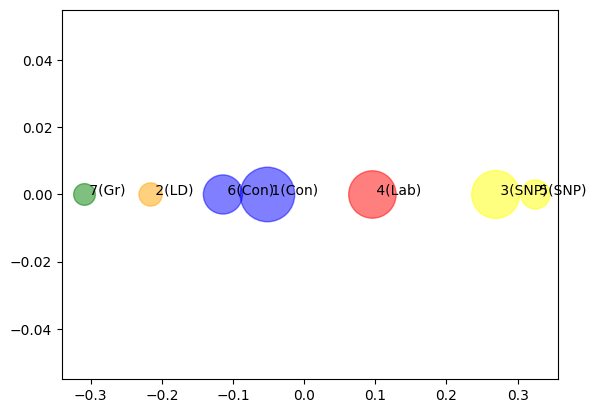

In [214]:
projections = MDS(n_components=1, dissimilarity='precomputed').fit_transform(M)
X = np.array([p[0] for p in projections])
Y = np.zeros(num_cands)
fig, ax = plt.subplots()
D = {'SNP':'yellow', 'Lab': 'red', 'Con':'blue','LD':'orange','Gr':'green'}
party_colors = []
for party in parties:
    party_colors.append(D[party] if party in D.keys() else 'black') 
s = [0 for _ in range(num_cands)]
for ballot,weight in election.items():
    s[ballot[0]-1]+=weight
ax.scatter(X,Y, c = party_colors, s=.5*np.array(s), alpha=.5)
for count in range(num_cands):
        ax.annotate(f" {count+1}({parties[count]})", xy=(X[count], Y[count]))

plt.show()

The following measured the "linearity" of an election in terms of the candidate distance matrix.  More precisely, it's the average over all triples of candidates of the linear deviation (a triple of candidates determines 3 distances, and the "linear deviation" means the abs of the difference between the largest and the sum of the other two).  

In [6]:
def Linearity(election, num_cands = 'Auto', method = 'borda_completion', trunc = None):
    if num_cands == 'Auto':
        num_cands = max([item for ranking in election.keys() for item in ranking])
    M = Candidate_dist_matrix(election, num_cands=num_cands, method=method, trunc=trunc)
    deviation = 0
    for a,b,c in combinations(range(num_cands),3):
        ls = [M[a,b], M[b,c], M[a,c]]
        ls.sort()
        [d1,d2,d3] = ls
        deviation += np.abs(d3-d1-d2)
    return deviation/math.comb(num_cands,3)     

In [7]:
Linearity(election)

1.8382383267049622

In [ ]:
# Compute Linearity of all Scottish elections with resepect to several similarity measurements.

filename_list = glob.glob(f"scot-elex/**/**.csv")
results = pd.DataFrame(columns=['filename', 'num_cands','dev_bord','dev_comp','dev_suc',
                                'dev_suc3','dev_co','dev_co3'])
counter = 0
for file in filename_list:
    num_cands, election, cand_names, location = csv_parse(file)
    dev_bord = Linearity(election, num_cands=num_cands, method='borda')
    dev_comp = Linearity(election, num_cands=num_cands, method='borda_completion')   
    dev_suc = Linearity(election, num_cands=num_cands, method='successive')
    dev_suc3 = Linearity(election, num_cands=num_cands, method='successive', trunc=3) 
    dev_co = Linearity(election, num_cands=num_cands, method='coappearances')
    dev_co3 = Linearity(election, num_cands=num_cands, method='coappearances', trunc=3)

    row_num = results.shape[0]
    results.loc[row_num] = [file, num_cands, dev_bord, dev_comp, dev_suc,
                            dev_suc3, dev_co, dev_co3]
    counter +=1
    if counter%10==0:
        print(counter)

In [8]:
def Candidate_gap_order(election, num_cands='Auto', all_truncations = True):
    """   
    Returns the order of the candidates that minimized the sum over the ballots of the gap-count.

    For a given order of the candidates, a ballot's gap-count is the number of candidates who are missing from the ballot but are between candidates on the ballot.  
    Set all-truncations = True if you also want to to sum over all truncations of all ballots.  

    Returns:
        best_perm, best_score 
    """
    if num_cands == 'Auto':
        num_cands = max([item for ranking in election.keys() for item in ranking])

    best_score = np.infty
    best_perm = None
    for perm in permutations(range(1,num_cands+1)):
        inverse_perm = Borda_vector(perm,num_cands=num_cands)
        points = 0
        for ballot,weight in election.items():
            ordered_ballot = [inverse_perm[cand-1] for cand in ballot]
            start = 2 if all_truncations else len(ordered_ballot)
            for trunc in range(start,len(ordered_ballot)+1):
                trunc_ballot = ordered_ballot[0:trunc]
                gaps = max(trunc_ballot)-min(trunc_ballot)+1-len(trunc_ballot)
                points += gaps*weight
        if points<best_score:
            best_score = points
            best_perm = perm

    return best_perm, best_score/sum(election.values())

In [70]:
perm, score = Candidate_gap_order(election)
for count in range(num_cands):
    print(count+1, cand_list[perm[count]-1])

1 ('Ernesta', 'Noreikiene', 'Scottish National Party (SNP)')
2 ('Neil', 'Gardiner', 'Scottish National Party (SNP)')
3 ('Evelyn', 'Weston', 'Green (Gr)')
4 ('Ricky', 'Henderson', 'Labour (Lab)')
5 ('Emma', 'Farthing', 'Liberal Democrat (LD)')
6 ('Graeme', 'Bruce', 'Conservative and Unionist Party (Con)')
7 ('Susan', 'Webber', 'Conservative and Unionist Party (Con)')


In [207]:
def Pancake_plot(election, clusters = None, cand_list=None, size = 10, 
                 num_cands = 'Auto', perm = 'Auto', filename=None,
                 draw_kde = True, draw_edges = True):
    """
    Plots a graph in which each row represents one of the `size` most frequently cast ballots
    (with the most popular ballots at the bottom).  
    The row's height equals the number of times the ballot was cast.  
    The darker shade represents the first place vote.  
      
    Args:
        election: dictionary matching ballots with weights
        clusters: pass a 2-clustering if you wish the graph to be colored by cluster assignment
        cand_list: must have the format that's returned by `csv_parse`
        perm: encodes the order of the candidates.  If perm == 'Auto', then `Candidate_gap_order` will determine it.
        filename: if you wish to save the plot
        draw_kde: Each ballot has a Borda-weighted center of mass on the horizontal axis.  Set draw_kde=True to include a kde plot of these centers of mass.
        draw_edges: set to `True` to draw a black edge around each row.
    """
    if num_cands == 'Auto':
        num_cands = max([item for ranking in election.keys() for item in ranking])
    if cand_list == None:
        cand_list = list(range(1, num_cands+1))
    if perm == 'Auto':
        perm, _ = Candidate_gap_order(election, num_cands=num_cands, all_truncations=True)
    all_ballots = [ballot for ballot in election.keys() if election[ballot]>0]

    # inverse_perm maps candidate {1,...,num_cands} to rankings {1,...,num_cands}
    inverse_perm = {x : perm.index(x)+1 for x in range(1,len(perm)+1)}

    # make list of shortened candidate names 
    short_cand_list = []
    for count in range(num_cands):
        cand = cand_list[perm[count]-1]
        last_name = cand[1]
        party = parties[perm[count]-1]
        short_cand_list.append(f"{last_name} ({party})")

    # create the axes
    fig, ax = plt.subplots()
    ax.set_xticks(range(1, num_cands+1))
    ax.set_xticklabels(short_cand_list, rotation=90)

    # loop over the most frequently cast ballots
    ls = sorted(set(election.values()))
    ballot_center_list = []
    bottom = 0
    count = 0
    broken = False
    while not broken:
        weight = ls.pop()        
        bs = [ballot for ballot in all_ballots if election[ballot]==weight]
        for ballot in bs:
            if clusters == None:
                color = 'purple'
            else:
                color = 'grey' if ballot in clusters[0].keys() else 'purple'
            ordered_ballot = [inverse_perm[x] for x in ballot]
            ax.bar(x=ordered_ballot, height = weight, width = 1, 
                   align = 'center', bottom = bottom,
                   color = (color,.5))
            # re-draw rectangle for first-place-vote to darken it:
            ax.bar(x=ordered_ballot[0], height = weight, width = 1, 
                   align = 'center', bottom = bottom,
                   color = (color,.5))
            
            if draw_edges:
                # draw box around the whole ballot
                left_edge = min(ordered_ballot)-.5
                width = max(ordered_ballot)-min(ordered_ballot)+1
                ax.bar(x=left_edge, height = weight, width = width,
                    align = 'edge', bottom = bottom, 
                    facecolor = 'none', edgecolor = 'black')
            
            count +=1
            bottom += weight+0

            # compute center that will be used for kde plot
            ballot_center = (sum([ordered_ballot[t]*(num_cands-t-1) for t in range(len(ballot))])/
                sum([(num_cands-t-1) for t in range(len(ballot))]))
            for _ in range(weight):
                ballot_center_list.append(ballot_center)

            if count>size:
                broken = True
                break

    if draw_kde:
        kde = gaussian_kde(ballot_center_list)
        x = np.linspace(0, num_cands+1, 500)
        y = kde(x)
        y_scaled = y*sum(election.values())
        ax.plot(x,y_scaled, color = 'black')

    if filename != None:
        plt.savefig(filename)
    plt.show()

In [173]:
C = kmeans(election)

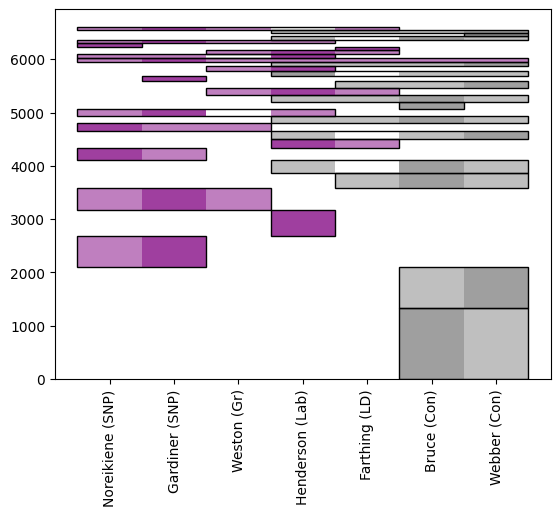

In [209]:
Pancake_plot(election, clusters=C, cand_list=cand_list, perm = perm, size=30, filename='test.jpg',
             draw_edges = True, draw_kde = False)

In [130]:
inverse_perm = [num_cands-x for x in Borda_vector(perm, num_cands=num_cands)]
print(perm)
print(inverse_perm)

(5, 3, 7, 4, 2, 1, 6)
[6, 5, 2, 4, 1, 7, 3]


In [134]:
inverse_perm = {x : perm.index(x)+1 for x in range(1,len(perm)+1)}
inverse_perm

{1: 6, 2: 5, 3: 2, 4: 4, 5: 1, 6: 7, 7: 3}

In [109]:
def Ballot_center_list(election, num_cands='Auto', all_truncations = True, perm = 'Auto'):
    if num_cands == 'Auto':
        num_cands = max([item for ranking in election.keys() for item in ranking])
    if perm == 'Auto':
        perm, score = Candidate_gap_order(election, num_cands=num_cands, all_truncations=all_truncations)
    inverse_perm = [num_cands-x for x in Borda_vector(perm, num_cands=num_cands)]
    ballot_centers = []
    for ballot,weight in election.items():
        ordered_ballot = tuple([inverse_perm[cand-1] for cand in ballot])
        x = (sum([ordered_ballot[t]*(num_cands-t-1) for t in range(len(ballot))])/
                sum([(num_cands-t-1) for t in range(len(ballot))]))
        for _ in range(weight):
            ballot_centers.append(x)

    return ballot_centers

In [19]:
bc = Ballot_center_list(election, perm=perm)

<Axes: ylabel='Count'>

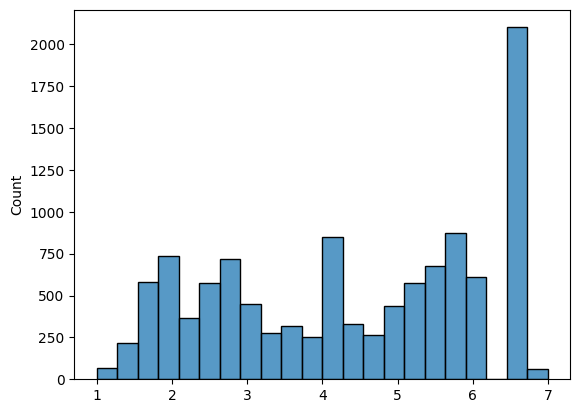

In [20]:
sns.histplot(bc)

In [21]:
def Linear_cluster(election, num_cands='Auto', all_truncations = False, cand_names = None):
    """
    Calls Candidate_gap_order to find the optimum ordering of the candidates, 
    and then clusters based on each ballot's center of mass along this ordered list.
    
    Args:
        election : dictionary matching ballots to weights.
        num_cands : set to 'Auto' to ask the algorithm to figure it out
        all_truncations : passed to Candidate_gap_order
        cand_names : an optimal re-ordering of this list will be returned 
    Returns:
        Clustering, ordered_candidate_list
    """
    if num_cands == 'Auto':
        num_cands = max([item for ranking in election.keys() for item in ranking])
    if cand_names == None:
        cand_names = range(1,num_cands+1)

    perm, score = Candidate_gap_order(election, num_cands=num_cands, all_truncations=False)
    inverse_perm = [num_cands-x for x in Borda_vector(perm, num_cands=num_cands)]

    # make dictionaries matching ballots to centers & first place votes
    # all with respect to the optimum ordering of the candidates
    ballot_center = dict()
    first_place_vote = dict()   
    for ballot,weight in election.items():
        ordered_ballot = tuple([inverse_perm[cand-1] for cand in ballot])
        first_place_vote[ballot]  = ordered_ballot[0]
        x = (sum([ordered_ballot[t]*(num_cands-t-1) for t in range(len(ballot))])/
                sum([(num_cands-t-1) for t in range(len(ballot))]))
        ballot_center[ballot] = x

    # Find the median of the ballot centers
    ballot_centers_with_repetition = []
    for ballot, weight in election.items():
        x = ballot_center[ballot]
        for _ in range(weight):
            ballot_centers_with_repetition.append(x)
    mid = np.median(ballot_centers_with_repetition)

    # form the clusters
    C = [dict(),dict()]
    for ballot,weight in election.items():
        x = ballot_center[ballot]
        fpv = first_place_vote[ballot]
        if x<mid or (x==mid and fpv<mid):
            C[0][ballot]=weight
        elif x>mid or (x==mid and fpv>mid):
            C[1][ballot]=weight
        else:
            C[np.random.choice([0,1])][ballot]=weight

    ordered_cand_list = [cand_names[x-1] for x in perm]
    return C, ordered_cand_list

In [38]:
filename_list = []
for n in range(5,8):
    filename_list.extend(glob.glob(f"scot-elex/{n}*/**.csv"))
len(filename_list)

597

In [ ]:
results = pd.DataFrame(columns=['filename', 'num_cands','lin', 'perms', 'score1', 'score2', 'std1','std2'])
counter = 0
for file in filename_list:
    num_cands, election, cand_names, location = csv_parse(file)
    lin = Linearity(election, num_cands=num_cands)/num_cands
    perm1,score1 = Candidate_gap_order(election, num_cands=num_cands, all_truncations=True)
    perm2,score2 = Candidate_gap_order(election, num_cands=num_cands, all_truncations=False)
    bc1 = Ballot_center_list(election, num_cands=num_cands,perm=perm1)
    bc2 = Ballot_center_list(election, num_cands=num_cands,perm=perm2)
    std1 = np.std(bc1)/(num_cands-1)
    std2 = np.std(bc2)/(num_cands-1)
    perms = {1:perm1, 2:perm2}

    row_num = results.shape[0]
    results.loc[row_num] = [file, num_cands, lin, perms, score1, score2, std1,std2]
    counter +=1
    if counter%10==0:
        print(counter)

In [75]:
results.to_pickle('linearity.pkl')

In [76]:
df = pd.read_pickle('results.pkl')
dfs = df[df['method']=='slate'] # only the slate trial of each election

In [77]:
sil = []
for index in results.index:
    full_filename=results['filename'][index]
    filename = full_filename.rsplit('\\', 1)[-1]
    R = dfs[dfs['filename']==filename]
    sil.append(R['sil'].mean())
results['sil']=sil

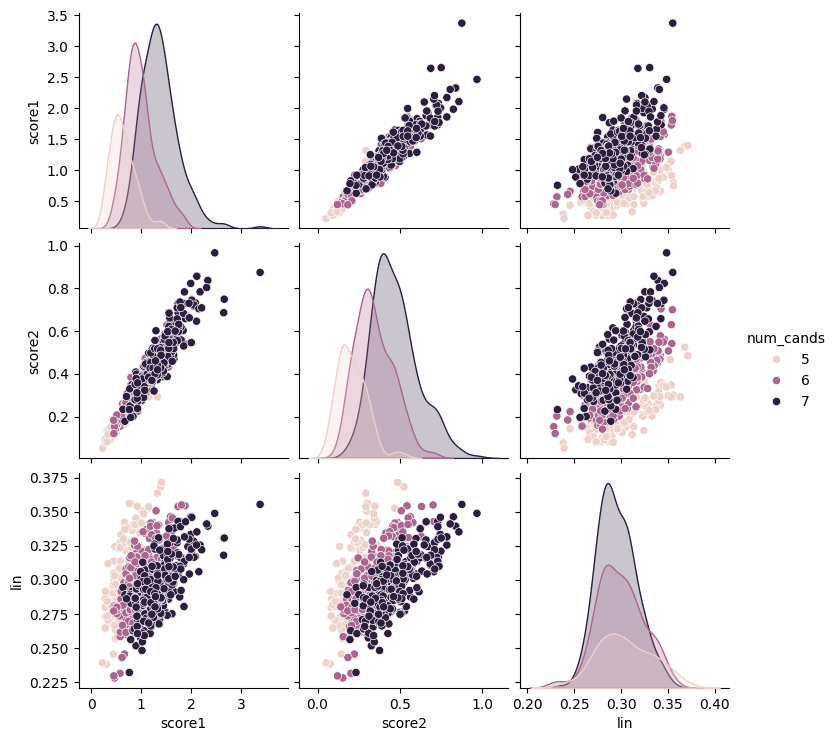

In [78]:
# linearity measurements
sns.pairplot(results[['score1', 'score2', 'lin', 'num_cands']], hue = 'num_cands')

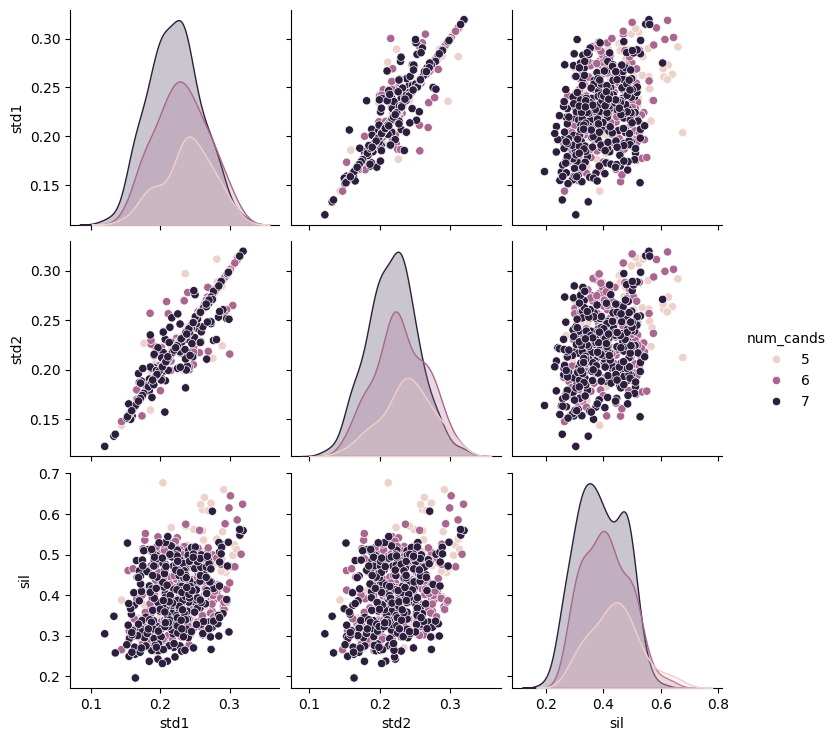

In [79]:
# polarization measurements
sns.pairplot(results[['std1', 'std2', 'sil', 'num_cands']], hue = 'num_cands')

In [81]:
yes_count = 0
no_count = 0
for index in results.index:
    perms = results['perms'][index]
    if perms[1]==perms[2]:
        yes_count +=1
    else:
        no_count +=1
print(yes_count,no_count)

378 219


In [99]:
results_0 = results[results['std1'] > results['std1'].quantile(.98)]
len(results_0)

12

scot-elex\5_cands\angus_2017_ward4.csv


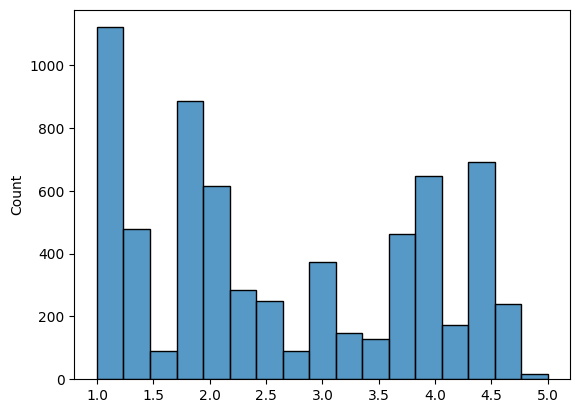

scot-elex\5_cands\dumgal_2017_ward11.csv


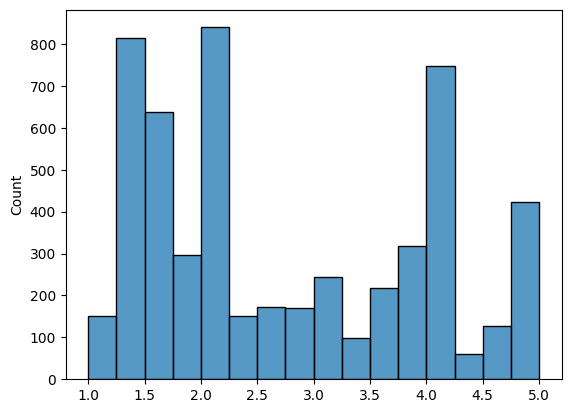

scot-elex\5_cands\moray_2022_ward4.csv


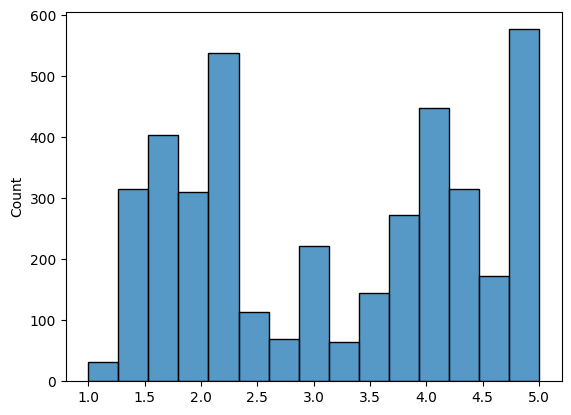

scot-elex\5_cands\south_ayrshire_2017_ward4.csv


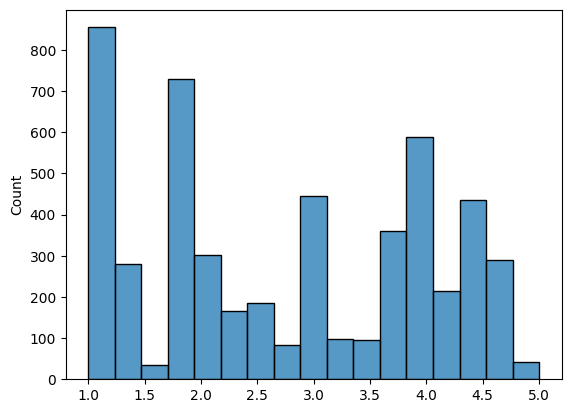

scot-elex\6_cands\angus_2017_ward1.csv


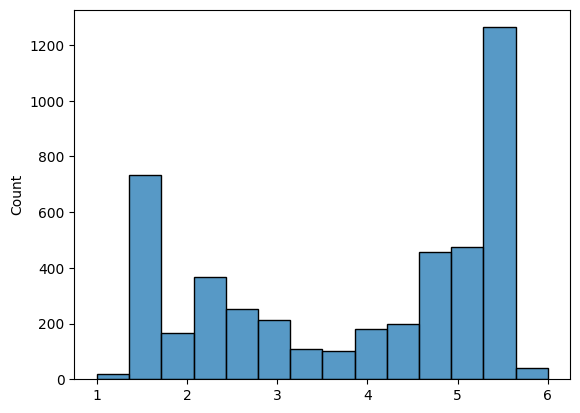

scot-elex\6_cands\clackmannanshire_2017_ward5.csv


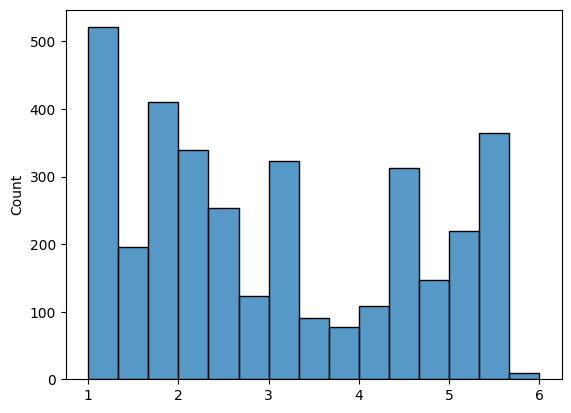

scot-elex\6_cands\perth_kinross_2017_ward1.csv


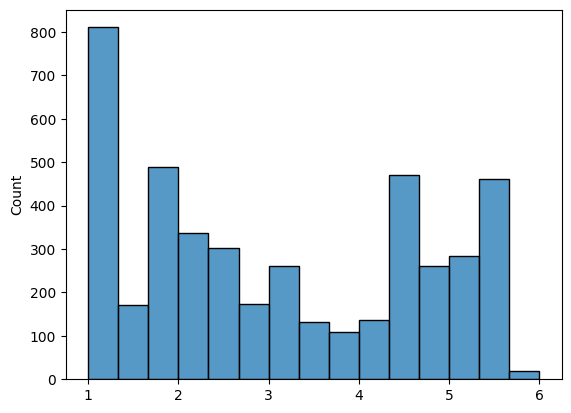

scot-elex\6_cands\perth_kinross_2017_ward3.csv


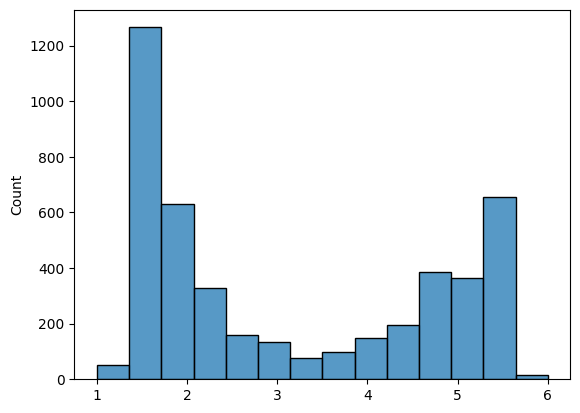

scot-elex\6_cands\stirling_2017_ward5.csv


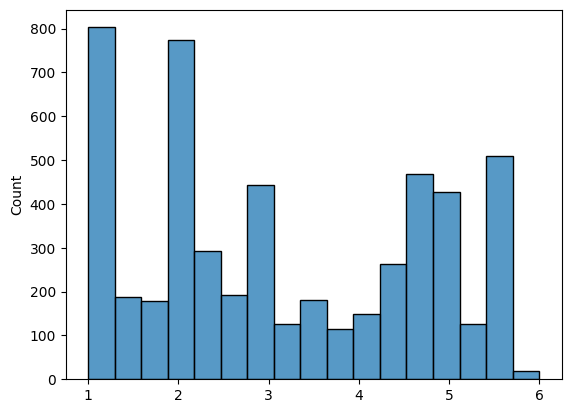

scot-elex\7_cands\angus_2022_ward1.csv


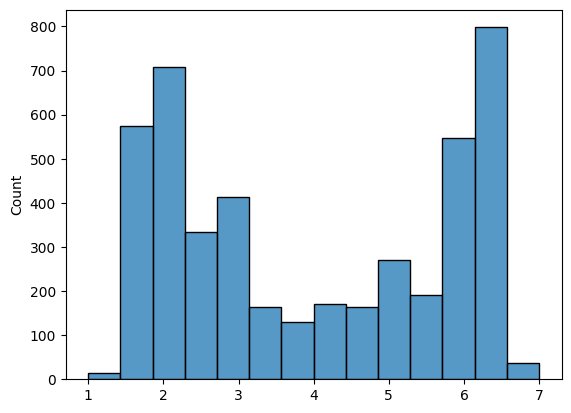

scot-elex\7_cands\perth_kinross_2017_ward5.csv


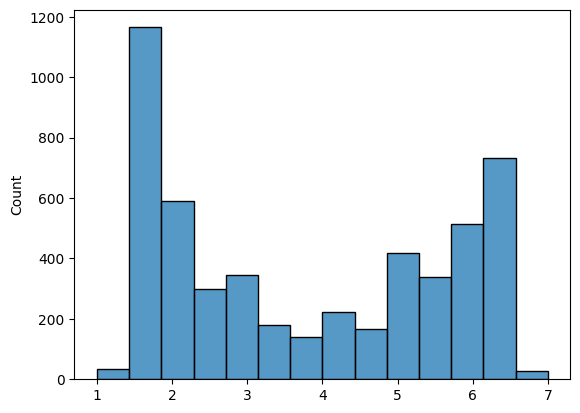

scot-elex\7_cands\stirling_2017_ward1.csv


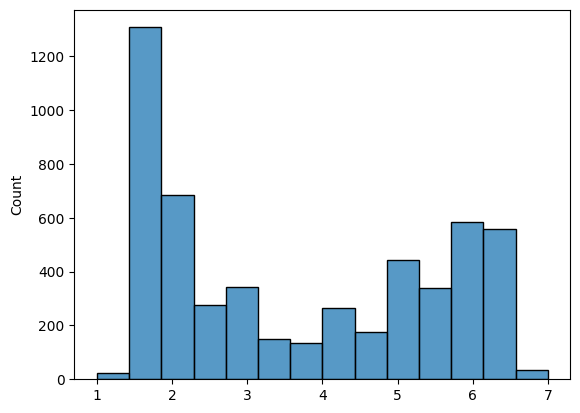

In [106]:
for index in results_0.index:
    filename = results_0['filename'][index]
    perm = results_0['perms'][index][1]
    print(filename)
    num_cands, election, cand_list, ward = csv_parse(filename)
    parties = party_abrevs(cand_list)
    bc = Ballot_center_list(election, num_cands=num_cands, perm = perm)
    plt.figure()
    fig = sns.histplot(bc)
    plt.show()


In [117]:
filename = 'scot-elex/6_cands/perth_kinross_2017_ward3.csv'
num_cands, election, cand_list, ward = csv_parse(filename)
parties = party_abrevs(cand_list)

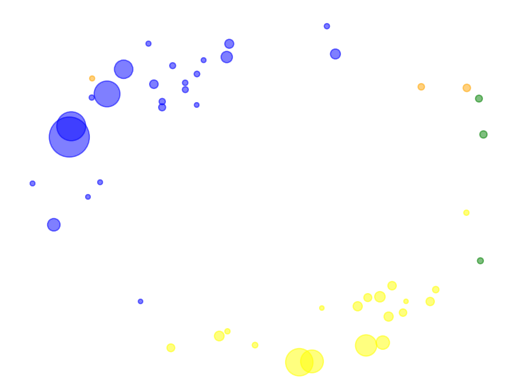

In [118]:
Ballot_MDS_plot(election,party_names=parties)

In [119]:
perm, score = Candidate_gap_order(election)

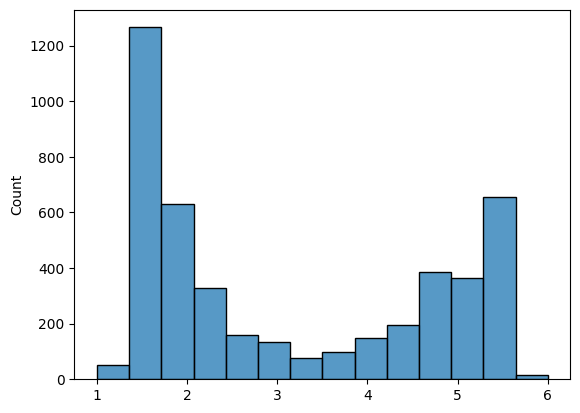

In [120]:
bc = Ballot_center_list(election, num_cands=num_cands, perm=perm)
plt.figure()
fig = sns.histplot(bc)
plt.show()

In [121]:
for count in range(1,num_cands+1):
    p = parties[perm[count-1]-1]
    print(count,p)

1 Con
2 Con
3 LD
4 Gr
5 SNP
6 SNP


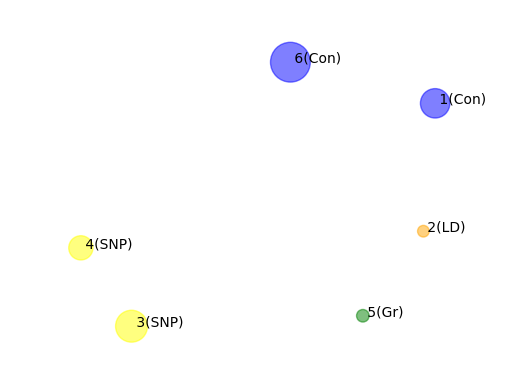

In [123]:
Candidate_MDS_plot(election, party_names=parties,party_colors='Auto')

In [124]:
results.columns

Index(['filename', 'num_cands', 'lin', 'perms', 'score1', 'score2', 'std1',
       'std2', 'sil'],
      dtype='object')

In [127]:
l = []
for index in results.index:
    filename = results['filename'][index]
    perms = results['perms'][index]
    num_cands, election, cand_list, ward = csv_parse(filename)
    parties = party_abrevs(cand_list)
    party_perms = {t: [ parties[perms[t][x]-1] for x in range(len(parties)) ]
                    for t in perms.keys()}
    l.append(party_perms)

In [129]:
results['party_perms']=l

In [130]:
for p in l:
    if p[1]==p[2]:
        print(p[1])
    else:
        print(p[1],p[2])

['SC', 'SNP', 'SNP', 'LD', 'Con'] ['SNP', 'SNP', 'SC', 'LD', 'Con']
['Con', 'LD', 'LD', 'SNP', 'Gr']
['SNP', 'SNP', 'Con', 'LD', 'Lab']
['Lab', 'SNP', 'LD', 'LD', 'Con']
['Gr', 'Con', 'LD', 'SNP', 'Lab'] ['Con', 'LD', 'SNP', 'Gr', 'Lab']
['Lab', 'SNP', 'LD', 'Con', 'Ind']
['Con', 'LD', 'Ind', 'SNP', 'SNP'] ['Con', 'Ind', 'LD', 'SNP', 'SNP']
['SNP', 'Ind', 'Ind', 'LD', 'Con'] ['SNP', 'Ind', 'LD', 'Con', 'Ind']
['SNP', 'SNP', 'Lab', 'LD', 'Con']
['Con', 'Con', 'LD', 'SNP', 'Gr']
['Con', 'LD', 'Lab', 'SNP', 'Gr']
['Con', 'LD', 'Lab', 'SNP', 'SNP']
['LD', 'Con', 'Ind', 'SNP', 'SNP']
['SNP', 'Lab', 'LD', 'Ind', 'Con']
['SNP', 'LD', 'LD', 'Con', 'Ind'] ['SNP', 'Ind', 'Con', 'LD', 'LD']
['SNP', 'Gr', 'LD', 'Con', 'Con']
['Lab', 'Lab', 'SNP', 'SNP', 'Con']
['Con', 'SNP', 'Lab', 'Lab', 'Lab']
['Con', 'Con', 'SNP', 'Lab', 'Lab']
['Con', 'Con', 'LD', 'Lab', 'SNP']
['Con', 'Ind', 'Lab', 'Lab', 'SNP']
['Gr', 'SNP', 'Lab', 'Con', 'Con'] ['SNP', 'Gr', 'Lab', 'Con', 'Con']
['SNP', 'Lab', 'LD', 'Con', 

In [131]:
filename = 'scot-elex/7_cands/edinburgh_2017_ward2.csv'
num_cands, election, cand_list, ward = csv_parse(filename)
parties = party_abrevs(cand_list)
perm, score = Candidate_gap_order(election)
ordered_parties = [ parties[perm[x]-1] for x in range(len(parties)) ]

In [132]:
ordered_parties

['SNP', 'SNP', 'Gr', 'Lab', 'LD', 'Con', 'Con']

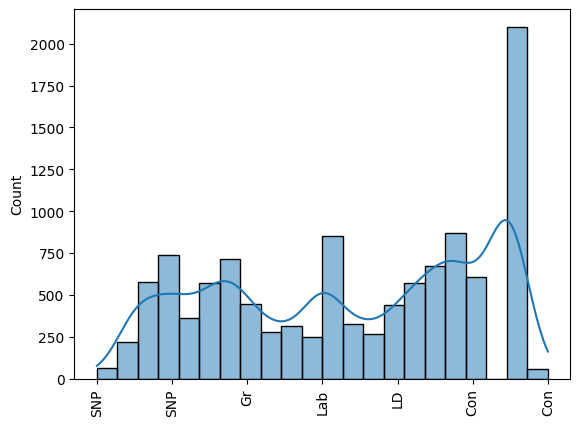

In [136]:
bc = Ballot_center_list(election, num_cands=num_cands, perm=perm)
plt.figure()
sns.histplot(bc, kde=True)
ax = plt.gca()
ax.set_xticks(range(1, 8))
ax.set_xticklabels(ordered_parties, rotation=90)
plt.show()

In [138]:
# separate all ballots into the ones with and without gaps.

inverse_perm = Borda_vector(perm,num_cands=num_cands)
good_ballots = dict()
bad_ballots = dict()

for ballot,weight in election.items():
    gap_free = True
    ordered_ballot = [inverse_perm[cand-1] for cand in ballot]
    for trunc in range(2,len(ordered_ballot)+1):
        trunc_ballot = ordered_ballot[0:trunc]
        gaps = max(trunc_ballot)-min(trunc_ballot)+1-len(trunc_ballot)
        if gaps>0:
            gap_free = False
    if gap_free:
        good_ballots[ballot]=weight
    else:
        bad_ballots[ballot]=weight

In [139]:
sum(good_ballots.values()), sum(bad_ballots.values())

(6317, 4998)

In [140]:
bc_good = Ballot_center_list(good_ballots, perm = perm)
bc_bad = Ballot_center_list(bad_ballots, perm = perm)